# MobileNetV3-Large — hard labels, verified-clean corpus

Fresh supervised training run. Replaces `emp_model_knowledge_distilation.ipynb`, which is discarded: its v6 teacher trained on contaminated data, so everything distilled from it inherited the contamination.

**No distillation, no teacher, no soft labels.** Plain class-balanced cross-entropy with label smoothing.

## What this notebook deliberately does NOT contain

It defines **no loader, no split, and no transforms of its own**. Every one of those is imported from the same code path the Airflow pipeline runs:

| Concern | Imported from | Not defined here because |
|---|---|---|
| split (train/val/holdout) | `train.prepare_data` → `coin_clf.data.active_split` | a second split definition is what produced three rival holdouts |
| datasets + transforms | `train.prepare_data` → `CoinImageDataset`, `coin_clf.transforms` | notebook/pipeline train-serve skew |
| sampler + loaders | `train.prepare_data` | silent drift in batch size / class balancing |
| scoring | `train.evaluate_hard`, `train.confusion_matrix` | a differently-computed accuracy is not comparable to `@champion` |
| LR schedule | `train.make_scheduler` | warmup/cosine must match the CLI run |

The **only** thing that lives here is the epoch loop itself, so it stays inspectable while you iterate.

The holdout is the canonical 11,559-image set (`build_manifest_holdout`), the same one `evaluate.py` and `promote.py` score against. Cell 3 asserts this by content-hash fingerprint before anything trains.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT))

import copy
from datetime import datetime

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from mlflow.models import infer_signature

# --- the canonical seams. Nothing below is reimplemented in this notebook. ---
from train import (
    class_display_order,
    confusion_matrix,
    evaluate_hard,
    make_scheduler,
    prepare_data,
)
from checkpoint import save_checkpoint
from coin_clf.labels import save_labels
from coin_clf.model import build_model

print(f"repo root: {REPO_ROOT}")

repo root: /home/david/coin


## Config

60 epochs is the real number, not a smoke-test value. The cosine schedule is defined over `EPOCHS × batches_per_epoch`, so a short run does not merely train less — it trains on a *different, truncated* LR curve that never decays. The previous 4-epoch / 0.73 result was mostly warmup (`WARMUP_EPOCHS = 2` of 4).

In [2]:
DATA_DIR = REPO_ROOT / "data" / "FOR_TRAINNING"

EPOCHS = 120
BATCH_SIZE = 256
LR = 3e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 2
GRAD_CLIP = 1.0
LABEL_SMOOTHING = 0.1
CLASS_BALANCE_BETA = 0.9999
SPLIT_SEED = 42
INPUT_SIZE = 224

TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "coin-classifier"
MODEL_NAME = "coin-classifier"

# Content-hash fingerprint of the canonical 11,559-image holdout, as proven by
# verify_data_integrity.py. If the next cell prints anything else, STOP: the holdout has moved
# and nothing trained here would be comparable to the current @champion.
CANONICAL_HOLDOUT_FP = "c47d3f321a0e13c2"

## Data — one call, one boundary

`prepare_data` runs `active_split`, which re-hashes both sides and refuses to return if any training image is byte-identical to a holdout image. That check runs below, before the model exists.

In [3]:
data = prepare_data(
    DATA_DIR,
    split_seed=SPLIT_SEED,
    batch_size=BATCH_SIZE,
    class_balance_beta=CLASS_BALANCE_BETA,
)

print()
print(data.summary())
print(f"train source  : {data.train_source}")
print(f"classes       : {data.num_classes}")
print(f"batches/epoch : {len(data.train_loader)}")

assert data.holdout_fingerprint == CANONICAL_HOLDOUT_FP, (
    f"holdout fingerprint {data.holdout_fingerprint} != canonical {CANONICAL_HOLDOUT_FP}. "
    "This run would be scored on a different set than evaluate.py / promote.py. "
    "Stop and run: PYTHONPATH=src python3 verify_data_integrity.py"
)
print(f"\nholdout is the canonical set ({CANONICAL_HOLDOUT_FP}) -- comparable to @champion")

active_split: hashing 35274 train + 11559 holdout image(s) to verify content-hash disjointness...
active_split: OK -- 35274 unique train hashes, 11559 unique holdout hashes, 0 collisions

train=28219  val=7055  holdout=11559  holdout_fingerprint=c47d3f321a0e13c2
train source  : data/active_train.txt
classes       : 51
batches/epoch : 111

holdout is the canonical set (c47d3f321a0e13c2) -- comparable to @champion


## Model, optimizer, schedule

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = build_model(data.num_classes, pretrained=True).to(device)
print(f"MobileNetV3-Large: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params")

cb_weights_dev = data.cb_weights.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

steps_per_epoch = len(data.train_loader)
total_steps = EPOCHS * steps_per_epoch
scheduler = make_scheduler(optimizer, total_steps, WARMUP_EPOCHS * steps_per_epoch)
print(f"{EPOCHS} epochs x {steps_per_epoch} batches = {total_steps} steps "
      f"({WARMUP_EPOCHS} warmup epochs, then cosine decay to 0)")

Device: cuda:0
MobileNetV3-Large: 4.3M params
120 epochs x 111 batches = 13320 steps (2 warmup epochs, then cosine decay to 0)


## Start the MLflow run

Needs `make mlflow` running in another terminal. Registered as a **challenger** — `@champion` is not touched here; promotion is a separate deliberate step (`promote.py`).

In [5]:
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
run = mlflow.start_run(run_name="mobilenetv3-hard-labels-notebook")
print("run_id:", run.info.run_id)

mlflow.log_params({
    "arch": "mobilenet_v3_large",
    "pretrained": True,
    "num_classes": data.num_classes,
    "input_size": INPUT_SIZE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "scheduler": "linear_warmup_cosine_decay",
    "warmup_epochs": WARMUP_EPOCHS,
    "grad_clip": GRAD_CLIP,
    "label_smoothing": LABEL_SMOOTHING,
    "class_balance_beta": CLASS_BALANCE_BETA,
    "sampler": "class_balanced_weighted_random",
    "objective": "cross_entropy_hard_labels",
    "split_seed": SPLIT_SEED,
    "train_source": data.train_source,
    "n_train": len(data.train_idx),
    "n_val": len(data.val_idx),
    "n_holdout": len(data.test_idx),
    # Provenance: which holdout this run's number was actually earned against.
    "holdout_fingerprint": data.holdout_fingerprint,
    "source": "notebooks/coin_mobilenet_hard_labels.ipynb",
})

run_id: 00e990a59be2499a90ee899b45757202


## Train

⏱ **This is the long cell — 60 epochs.** Everything above is cheap and re-runnable; nothing below starts until you run this.

In [6]:
best_val_acc, best_state = 0.0, None
history = []

for epoch in range(1, EPOCHS + 1):
    t0 = datetime.now()
    model.train()
    running_loss = 0.0

    for imgs, labels in data.train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(imgs), labels, weight=cb_weights_dev,
                               label_smoothing=LABEL_SMOOTHING)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()

    val_acc = evaluate_hard(model, data.val_loader, device)
    train_loss = running_loss / len(data.train_loader)
    lr_now = optimizer.param_groups[0]["lr"]
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())

    mlflow.log_metrics({"train_loss": train_loss, "val_acc": val_acc, "lr": lr_now}, step=epoch)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_acc": val_acc, "lr": lr_now})
    print(f"ep {epoch:3d}/{EPOCHS}  loss {train_loss:.4f}  val {val_acc:.4f}  "
          f"lr {lr_now:.2e}  [{datetime.now() - t0}]" + ("  <--" if improved else ""))

print(f"\nBest val acc: {best_val_acc:.4f}")

ep   1/120  loss 3.3907  val 0.0370  lr 1.50e-04  [0:01:00.391390]  <--
ep   2/120  loss 2.0107  val 0.3582  lr 3.00e-04  [0:00:48.589721]  <--
ep   3/120  loss 1.4051  val 0.6081  lr 3.00e-04  [0:00:52.945856]  <--
ep   4/120  loss 1.1445  val 0.6913  lr 3.00e-04  [0:00:48.070525]  <--
ep   5/120  loss 1.0013  val 0.7514  lr 3.00e-04  [0:00:50.983598]  <--
ep   6/120  loss 0.9397  val 0.7670  lr 2.99e-04  [0:00:48.978996]  <--
ep   7/120  loss 0.8752  val 0.8027  lr 2.99e-04  [0:00:47.389649]  <--
ep   8/120  loss 0.8298  val 0.8245  lr 2.98e-04  [0:00:49.927133]  <--
ep   9/120  loss 0.8040  val 0.8262  lr 2.97e-04  [0:00:48.070407]  <--
ep  10/120  loss 0.7839  val 0.8235  lr 2.97e-04  [0:00:47.969842]
ep  11/120  loss 0.7686  val 0.8473  lr 2.96e-04  [0:00:51.288774]  <--
ep  12/120  loss 0.7463  val 0.8517  lr 2.95e-04  [0:00:48.403394]  <--
ep  13/120  loss 0.7417  val 0.8543  lr 2.94e-04  [0:00:51.069076]  <--
ep  14/120  loss 0.7211  val 0.8663  lr 2.92e-04  [0:00:48.765524]  <

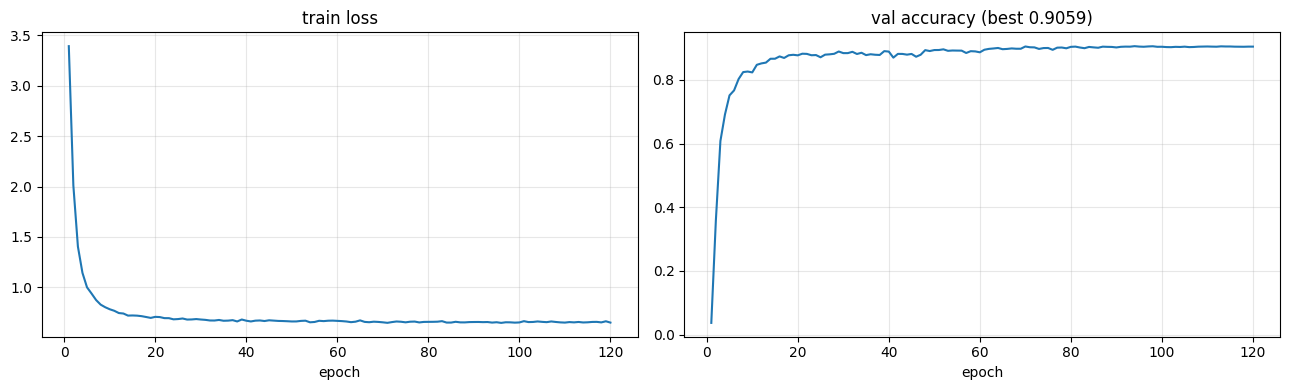

In [7]:
hist = pd.DataFrame(history).set_index("epoch")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
hist["train_loss"].plot(ax=ax1, title="train loss")
hist["val_acc"].plot(ax=ax2, title=f"val accuracy (best {best_val_acc:.4f})")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
fig.tight_layout()
mlflow.log_figure(fig, "training_curves.png")
plt.show()

## Score on the canonical holdout

Best-val weights, scored on the same 11,559 images `evaluate.py` and `promote.py` use — so this number is directly comparable to `@champion`'s.

In [8]:
model.load_state_dict(best_state)
model.eval()

ckpt_path = save_checkpoint(best_state, str(REPO_ROOT / "weights"), run.info.run_id)
print(f"weights -> {ckpt_path}")

test_acc = evaluate_hard(model, data.test_loader, device)
print(f"Holdout acc: {test_acc:.4f}  on {len(data.test_idx)} images "
      f"(fingerprint {data.holdout_fingerprint})")
mlflow.log_metrics({"best_val_acc": best_val_acc, "test_acc": test_acc})

weights -> /home/david/coin/weights/student_00e990a59be2499a90ee899b45757202.pth
Holdout acc: 0.9030  on 11559 images (fingerprint c47d3f321a0e13c2)


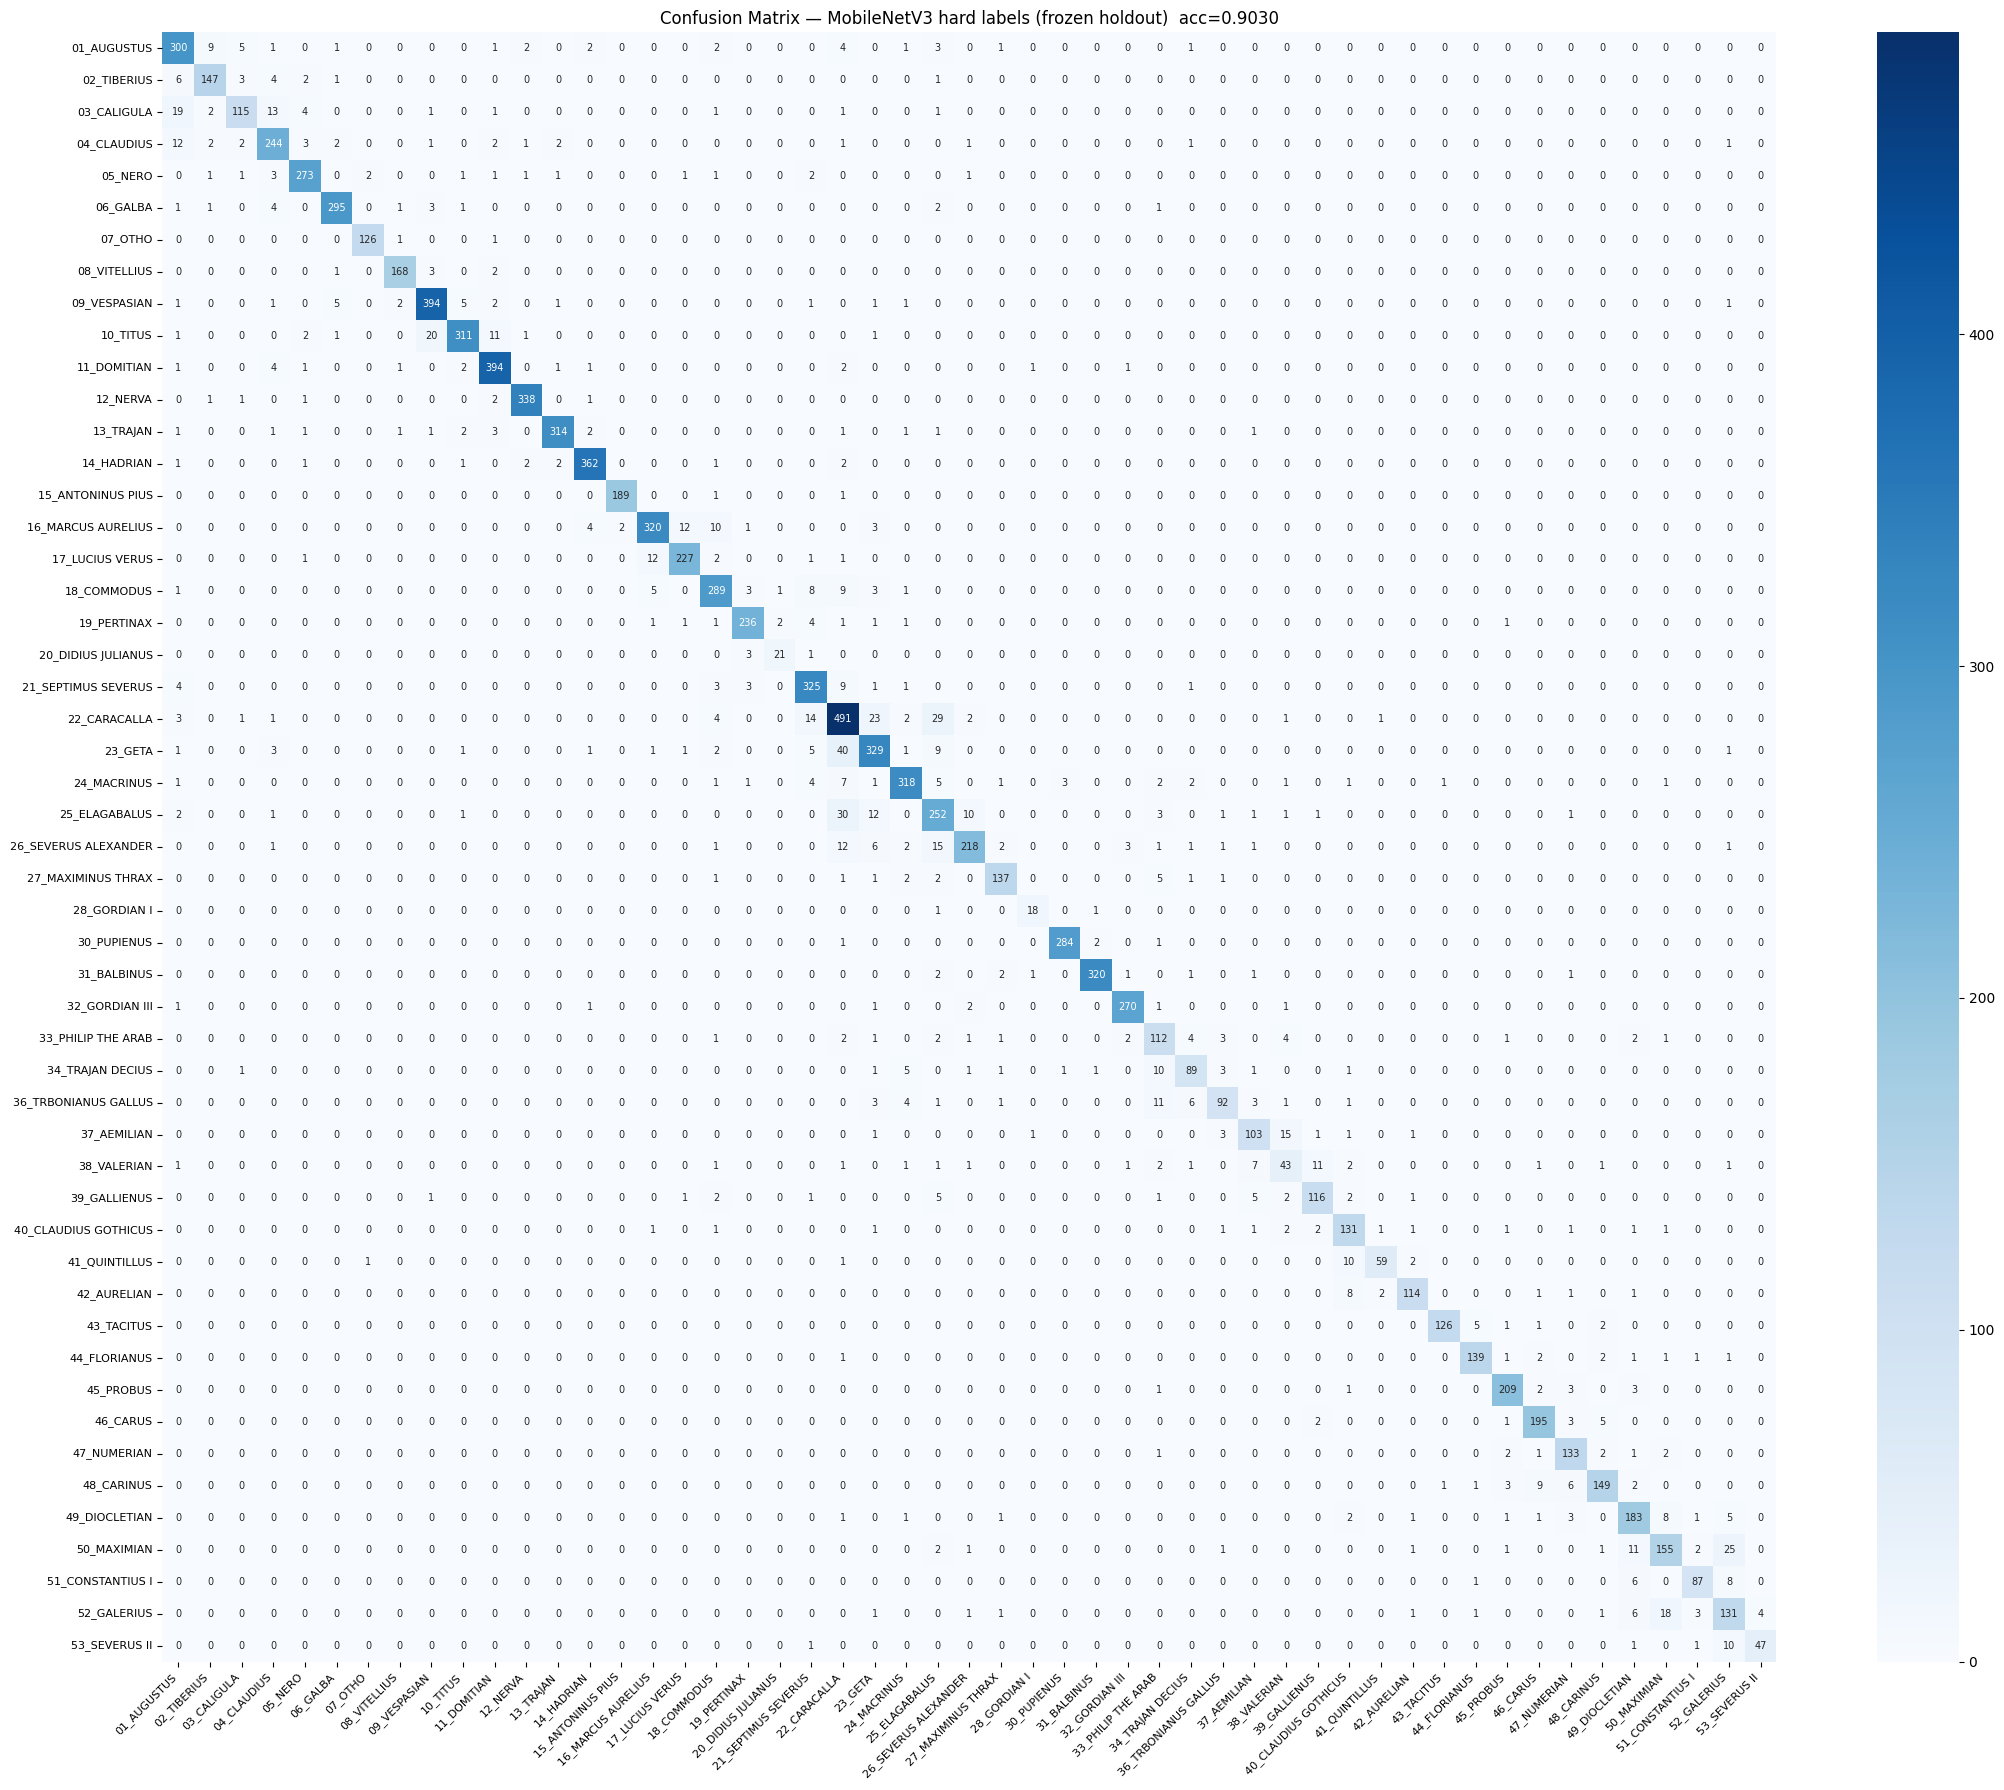


Weakest 10 classes:
  0.566  VALERIAN  (n=76)
  0.728  CALIGULA  (n=158)
  0.748  TRBONIANUS GALLUS  (n=123)
  0.774  TRAJAN DECIUS  (n=115)
  0.775  MAXIMIAN  (n=200)
  0.780  GALERIUS  (n=168)
  0.783  SEVERUS II  (n=60)
  0.797  ELAGABALUS  (n=316)
  0.808  QUINTILLUS  (n=73)
  0.817  AEMILIAN  (n=126)


In [9]:
cm = confusion_matrix(model, data.test_loader, device, data.num_classes)
row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
mlflow.log_metrics({f"class_acc/{data.idx_to_label[i]}": float(row_acc[i])
                    for i in range(data.num_classes)})

class_order, display_names = class_display_order(DATA_DIR, data.idx_to_label, data.num_classes)
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(pd.DataFrame(cm[np.ix_(class_order, class_order)],
                         index=display_names, columns=display_names),
            annot=True, fmt="d", cmap="Blues", annot_kws={"size": 7}, ax=ax)
ax.set_title(f"Confusion Matrix — MobileNetV3 hard labels (frozen holdout)  acc={test_acc:.4f}")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
fig.tight_layout()
mlflow.log_figure(fig, "confusion_matrix.png")
plt.show()

worst = sorted(range(data.num_classes), key=lambda i: row_acc[i])[:10]
print("\nWeakest 10 classes:")
for i in worst:
    print(f"  {row_acc[i]:.3f}  {data.idx_to_label[i]}  (n={cm.sum(axis=1)[i]})")

## Register as a challenger

In [10]:
save_labels(data.idx_to_label, str(REPO_ROOT / "weights" / "coin_labels.json"))

model.eval()
model.to("cpu")
example_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)
with torch.no_grad():
    example_output = model(example_input)
signature = infer_signature(example_input.numpy(), example_output.numpy())

model_info = mlflow.pytorch.log_model(
    pytorch_model=model,
    name="model",  # if this errors on an older client: change to artifact_path="model"
    signature=signature,
    input_example=example_input.numpy(),
    serialization_format="pickle",
)
mlflow.end_run()

mv = mlflow.register_model(model_info.model_uri, MODEL_NAME)
print(f"Registered {MODEL_NAME} v{mv.version} — challenger only, @champion unchanged")

2026/08/24 00:09:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


🏃 View run mobilenetv3-hard-labels-notebook at: http://127.0.0.1:5000/#/experiments/2/runs/00e990a59be2499a90ee899b45757202
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


Registered model 'coin-classifier' already exists. Creating a new version of this model...
2026/08/24 00:09:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: coin-classifier, version 6
Created version '6' of model 'coin-classifier'.


Registered coin-classifier v6 — challenger only, @champion unchanged


## Next: promote (separate, deliberate step)

```bash
# score it standalone
PYTHONPATH=src python3 evaluate.py --version <v> --data-dir data/FOR_TRAINNING

# gate it against the current champion on the same holdout
PYTHONPATH=src python3 promote.py --challenger <v> --data-dir data/FOR_TRAINNING --dry-run
```

Drop `--dry-run` to actually move the `@champion` alias. There is no champion for a fresh registry, in which case `promote.py` bootstraps this version as champion.